<a href="https://colab.research.google.com/github/sakshi79/CS7180/blob/main/translationMLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# imports
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from scipy.ndimage import shift  # used for translating pixels in an image
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
%matplotlib inline

from typing import Any, Dict, Tuple, Union

In [2]:
# Runtime
if torch.cuda.is_available() and torch.cuda.device_count() > 0:
  print("PyTorch running on a GPU. Use '.to(device)' to move tensors and models to GPU.")
  device = torch.device("cuda:0")
else:
  print("WARNING: PyTorch running on a CPU")
  device = torch.device("cpu")

PyTorch running on a GPU. Use '.to(device)' to move tensors and models to GPU.


In [3]:
t = transforms.ToTensor()
batch_size = 128
train_ds = datasets.MNIST("/tmp/mnist", download=True, train=True, transform=t)
eval_ds = datasets.MNIST("/tmp/mnist", download=True, train=False, transform=t)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
eval_loader = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=1)

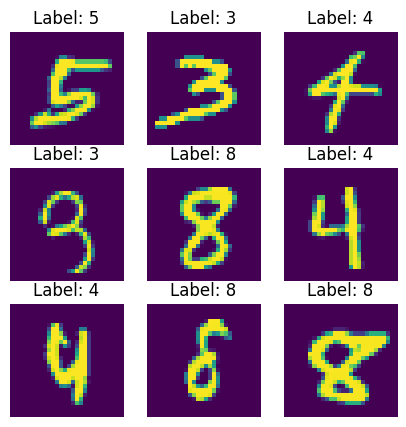

In [4]:
example = next(iter(train_loader))
plt.figure(figsize=(5, 5))
for i in range(3*3):
  plt.subplot(3, 3, 1 + i)
  plt.title("Label: {:d}".format(example[1][i]))
  plt.imshow(example[0][i][0])
  plt.axis("off")

## Training a baseline

In [5]:
class MLPBaseline(nn.Module):
  """A Multi Layer Perceptron baseline.
  It flattens the input image and applies three fully-connected layers
  each followed by an activation."""
  def __init__(self):
    super().__init__()

    input_dim = 28*28
    hidden_dim = 128
    output_dim = 10

    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.fc2 = nn.Linear(hidden_dim, hidden_dim)
    self.fc3 = nn.Linear(hidden_dim, output_dim)
    self.act = nn.ReLU()

  def forward(self, x: torch.Tensor) -> torch.Tensor:

    x = x.reshape(x.shape[0], -1)

    x = self.act(self.fc1(x))
    x = self.act(self.fc2(x))
    # Our loss function expect log probabilities of the 10 digit classes.
    x = F.log_softmax(self.fc3(x), dim=-1)

    return x

In [6]:
def train(train_loader: DataLoader, model: nn.Module, optimizer: optim.Optimizer, epochs: int):

    losses = []

    for epoch in range(epochs):
      print("Epoch {:d} / {:d}".format(epoch, epochs))
      for train_step, batch in enumerate(train_loader):
        inputs, labels = batch[0].to(device), batch[1].to(device)
        # Reset last optimization step.
        optimizer.zero_grad()
        # Make prediction, calculate loss.
        outputs = model(inputs)
        loss = F.nll_loss(outputs, labels)
        # Compute gradients and update weights.
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if train_step > 0 and train_step % 100 == 0:
          print("Mean of last 100 losses: {:f}".format(np.mean(losses[-100:])))

    #return losses
    plt.plot(losses)
    plt.xlabel("Training step")
    plt.ylabel("Loss")

In [7]:
# Eval
@torch.no_grad()

def evaluate(eval_loader: DataLoader, model: nn.Module):
  accuracy = []
  for batch in eval_loader:
      inputs, labels = batch[0].to(device), batch[1].to(device)
      outputs = model(inputs)
      pred_labels = torch.argmax(outputs, dim=-1)
      acc = (labels == pred_labels).float().mean()
      accuracy.append(acc.item())
  accuracy = np.mean(accuracy)
  print("Correct answer in {:.1f}% of cases.".format(accuracy * 100))
  return accuracy

In [8]:
@torch.no_grad()
def plot_predictions(eval_loader: DataLoader, model: nn.Module):
    example = next(iter(eval_loader))
    inputs = example[0].to(device)
    outputs = model(inputs)
    pred_labels = torch.argmax(outputs, dim=-1).to("cpu").numpy()

    plt.figure(figsize=(5, 5))
    for i in range(3*3):
      plt.subplot(3, 3, 1 + i)
      plt.title("Label: {:d}".format(pred_labels[i]))
      plt.imshow(example[0][i][0])
      plt.axis("off")

Epoch 0 / 5
Mean of last 100 losses: 0.833927
Mean of last 100 losses: 0.322054
Mean of last 100 losses: 0.283629
Mean of last 100 losses: 0.222996
Epoch 1 / 5
Mean of last 100 losses: 0.174095
Mean of last 100 losses: 0.165116
Mean of last 100 losses: 0.144412
Mean of last 100 losses: 0.137384
Epoch 2 / 5
Mean of last 100 losses: 0.113031
Mean of last 100 losses: 0.107985
Mean of last 100 losses: 0.102213
Mean of last 100 losses: 0.102762
Epoch 3 / 5
Mean of last 100 losses: 0.083289
Mean of last 100 losses: 0.088966
Mean of last 100 losses: 0.076555
Mean of last 100 losses: 0.080145
Epoch 4 / 5
Mean of last 100 losses: 0.062378
Mean of last 100 losses: 0.064502
Mean of last 100 losses: 0.064440
Mean of last 100 losses: 0.066769


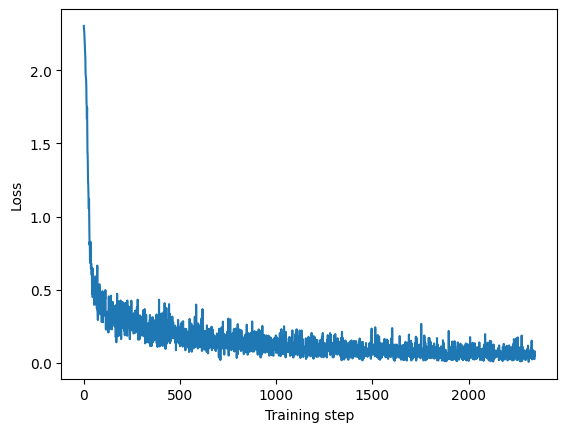

In [9]:
trained_mlp = MLPBaseline().to(device)
optimizer = optim.Adam(trained_mlp.parameters(), lr=0.001)
train(train_loader, trained_mlp, optimizer, 5)

In [10]:
evaluate(eval_loader, trained_mlp)

Correct answer in 97.5% of cases.


np.float64(0.9749802215189873)

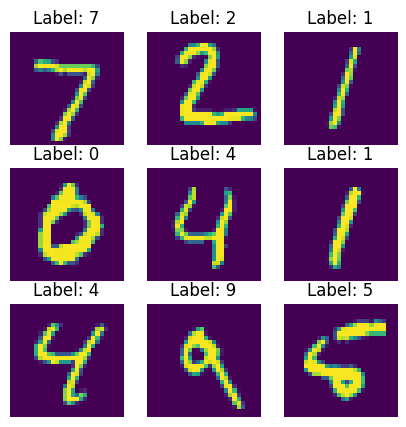

In [11]:
plot_predictions(eval_loader, trained_mlp)

### Let's now introduce translation in these images

In [12]:
def translate(image: Union[torch.Tensor, NDArray], delta_x: float, delta_y: float) -> Union[torch.Tensor, NDArray]:
  """Translate an image. Either torch.Tensor or numpy.ndarray. Can be HxWxC or CxHxW."""
  is_torch = False
  if type(image) == torch.Tensor:
    # Pytorch to numpy.
    is_torch = True  # need this to convert back to torch later
    tmp = image.to("cpu").detach().numpy()
  else:
    tmp = image

  if len(tmp.shape) == 2:
    # HxW
    delta = [delta_x, delta_y]
  else:
    assert len(tmp.shape) == 3, "Invalid number of dimensions in an image, should be 2 or 3."
    if tmp.shape[0] in [1, 3]:
      # CxHxW
      delta = [0, delta_x, delta_y]
    elif tmp.shape[2] in [1, 3]:
      # HxWxC
      delta = [delta_x, delta_y, 0]
    else:
      raise ValueError("Invalid number of channels in an image, should be 1 or 3.")

  # Shift and automatically add zero padding.
  tmp = shift(image, delta)

  if is_torch:
    tmp = torch.tensor(tmp, dtype=image.dtype, device=image.device)
  return tmp

In [13]:
import random
x_shift = random.choice([-2, -3, -5, 2, 3, 5])
y_shift = random.choice([-2, -3, -5, 2, 3, 5])

In [14]:
from torch.utils.data import Subset
num_samples = 200
subset = Subset(eval_ds, range(num_samples))
test_loader = DataLoader(subset, batch_size=num_samples, shuffle=False, num_workers=1)
example = next(iter(test_loader))

untrained_mlp = MLPBaseline().to(device)

In [15]:
accuracy_trained = []
accuracy_untrained = []

for i in range(num_samples):
    image = example[0]
    label = example[1]
    translated_imgs = [translate(img, x_shift, y_shift) for img in image]
    arr = np.stack(translated_imgs, axis=0)      # shape: (N, H, W, C)
    translated_images = torch.from_numpy(arr)
    translated_images = translated_images.to(device)

    trained_out = trained_mlp(translated_images)
    trained_out = torch.argmax(trained_out, dim=-1).to("cpu")
    acc_trained = (trained_out==label).float()
    accuracy_trained.append(acc_trained)

    untrained_out = untrained_mlp(translated_images)
    untrained_out = torch.argmax(untrained_out, dim=-1).to("cpu")
    acc_untrained = (untrained_out==label).float()
    accuracy_untrained.append(acc_untrained)

trained_acc = np.mean(accuracy_trained)
untrained_acc = np.mean(accuracy_untrained)

print("Accuracy of trained MLP on translated images: {:.2f}%".format(trained_acc))
print("Accuracy of untrained MLP on translated images: {:.2f}%".format(untrained_acc))


Accuracy of trained MLP on translated images: 0.17%
Accuracy of untrained MLP on translated images: 0.10%


We see that:
1. Performance of trained MLP on untranslated images is 98%.
2. Performance of same trained MLP on translated images drops down to 57%.
3. Performance of an untrained MLP on translated images is 17%.
We conclude that MLPs are not translation invariant.